In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("../data")
MONTHLY_DIR = DATA_DIR / "parquet" / "monthly"
YEARS = [2020, 2021, 2022, 2023, 2024]

df = pd.concat(
    [
        pd.read_parquet(MONTHLY_DIR / f"fleet-monthly-{y}.parquet", columns=["year", "flag", "fishing_hours"])
        for y in YEARS
    ],
    ignore_index=True,
)

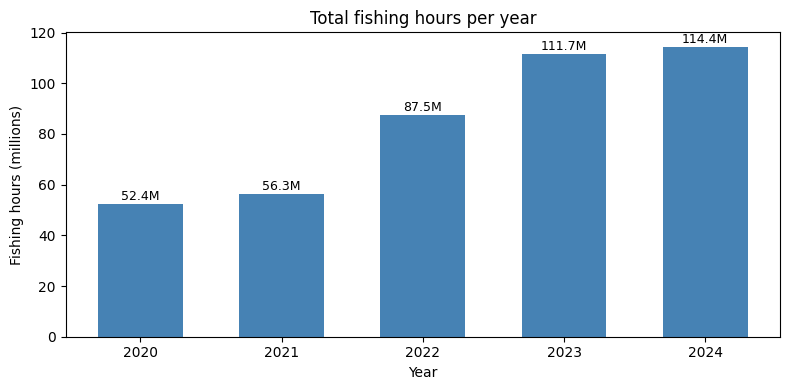

In [2]:
# Total fishing hours per year
yearly = df.groupby("year")["fishing_hours"].sum() / 1e6  # millions of hours

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(yearly.index, yearly.values, color="steelblue", width=0.6)
ax.set_xlabel("Year")
ax.set_ylabel("Fishing hours (millions)")
ax.set_title("Total fishing hours per year")
ax.set_xticks(YEARS)
for x, y in zip(yearly.index, yearly.values):
    ax.text(x, y + 0.3, f"{y:.1f}M", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

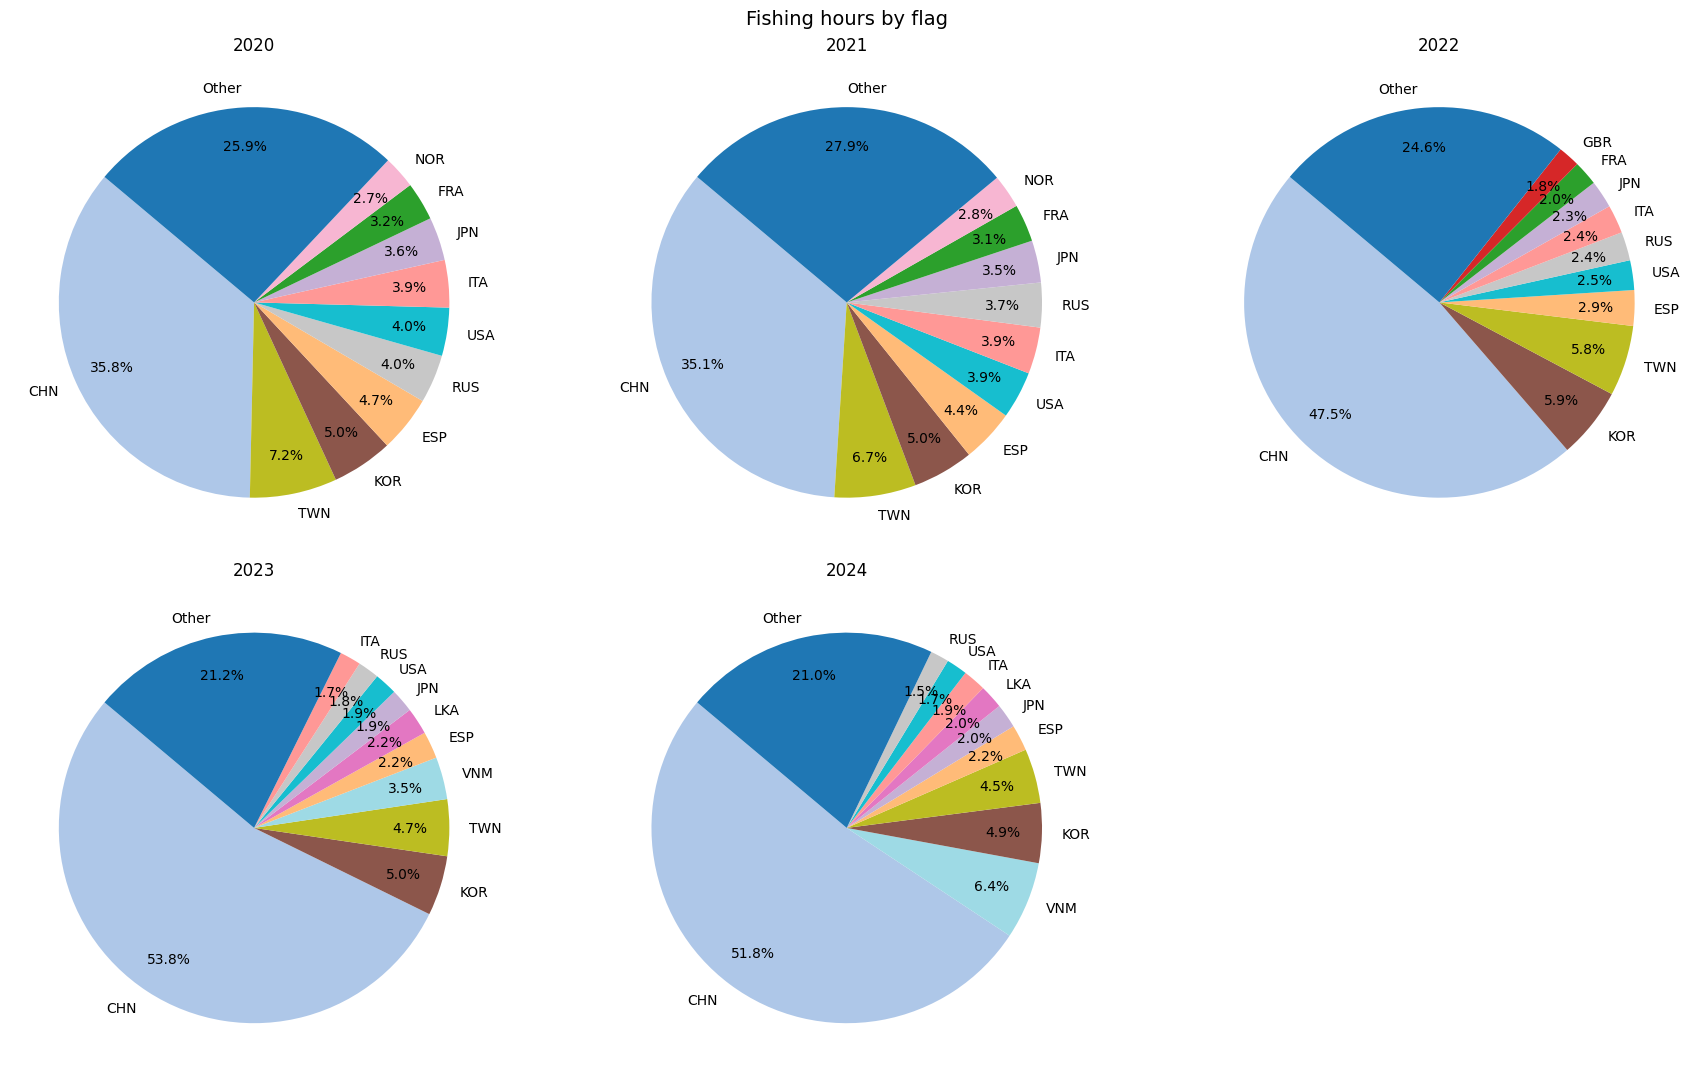

In [8]:
# Fishing hours by flag — top 10 + other, one pie per year, consistent colors

# First pass: collect all flags that appear in any year's top 10
def get_top10_other(year_df):
    flag_col = year_df["flag"].astype(str).str.replace(r"^UNKNOWN-", "", regex=True)
    by_flag = year_df["fishing_hours"].groupby(flag_col).sum().sort_values(ascending=False)
    top10 = by_flag.head(10)
    other = by_flag.iloc[10:].sum()
    return pd.concat([top10, pd.Series({"Other": other})])

yearly_data = {year: get_top10_other(df[df["year"] == year]) for year in YEARS}

all_flags = ["Other"] + sorted({f for pie in yearly_data.values() for f in pie.index if f != "Other"})
colors = plt.cm.tab20.resampled(len(all_flags)).colors
color_map = dict(zip(all_flags, colors))

# Second pass: plot
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for ax, year in zip(axes, YEARS):
    pie_data = yearly_data[year]
    ax.pie(
        pie_data.values,
        labels=pie_data.index,
        autopct="%1.1f%%",
        startangle=140,
        pctdistance=0.8,
        colors=[color_map[f] for f in pie_data.index],
    )
    ax.set_title(str(year))

axes[-1].set_visible(False)
fig.suptitle("Fishing hours by flag", fontsize=14)
plt.tight_layout()
plt.show()